In [1]:
import matplotlib as mpl
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from cmcrameri import cm
import os
from copy import deepcopy


from inferagni.plot import truth_color, samples_color, DPI
from inferagni.util import varprops

/home/harrison/miniforge3/envs/proteus/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/harrison/.var/app/com.visualstudio.code/config', but the default location, /home/harrison/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [2]:
# %config InlineBackend.figure_format = 'retina'

In [66]:
cases = {"Neither":None,  "Fbol":None, "MMW":None, "Fbol+MMW":None,}

outdir = "output/"
planet = "pi_Men_c"
end_frac = 0.05

for k in cases.keys():
    outdir_planet = os.path.join(outdir,f"{planet}({k})")
    print(outdir_planet)

    samps = pd.read_csv(os.path.join(outdir_planet,"result.csv"),skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(os.path.join(outdir_planet,"truth.csv" ),skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # sort samples into best-fit order
    r_phot_obs = truth.loc[truth["key"]=="r_phot"]["value"].iloc[0]
    mask = np.argsort(np.abs(samps["r_phot"].values - r_phot_obs))[::-1]
    samps = samps.iloc[mask]

    # get last samples from samps
    nsamp = int(len(samps)*end_frac)
    print(f"Number of samples: {len(samps)}")
    samps = samps.iloc[-nsamp:]

    cases[k] = {"samps":samps, "truth":truth}

    print(truth.keys())
    print(samps.keys())
    print("")

output/pi_Men_c(Neither)
Number of samples: 52920
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2S', 'μ_phot', 'r_phot', 'log_Kzz_max',
       'log_vmr_H2O', 'log_vmr_CO2', 'log_vmr_H2', 't_surf'],
      dtype='str')

output/pi_Men_c(Fbol)
Number of samples: 52920
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_CO2', 't_surf', 'log_vmr_H2O', 'log_Kzz_max',
       'log_vmr_H2', 'log_vmr_H2S', 'r_phot', 'μ_phot'],
      dtype='str')

output/pi_Men_c(MMW)
Number of samples: 28333
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2O', 'log_vmr_CO2', 'μ_phot', 'log_vmr_H2',
       'r_phot', 'log_Kzz_max', 't_surf', 'log_vmr_H2S'],
      dtype='str')

output/pi_Men_c(Fbol+MM

Neither
    Greens
    Nsamps: 2646
    Counts: 1.0e-05 - 1.3e-02
    frac_atm        : 0.00345034 (0.00235919 , 0.0193691)
    log_vmr_H2O     : -1.51813 (1.30124 , 0.732632)
Fbol
    Reds
    Nsamps: 2646
    Counts: 1.0e-05 - 1.5e-02
    frac_atm        : 0.00305669 (0.00216917 , 0.0176861)
    log_vmr_H2O     : -1.20513 (0.956133 , 0.534819)
MMW
    Blues
    Nsamps: 1416
    Counts: 1.0e-05 - 3.4e-02
    frac_atm        : 0.0305784 (0.0237169 , 0.0578222)
    log_vmr_H2O     : -0.725328 (0.362003 , 0.359094)
Fbol+MMW
    Greys
    Nsamps: 1323
    Counts: 1.0e-05 - 4.0e-02
    frac_atm        : 0.0171042 (0.0132534 , 0.0441885)
    log_vmr_H2O     : -0.743472 (0.147371 , 0.245699)


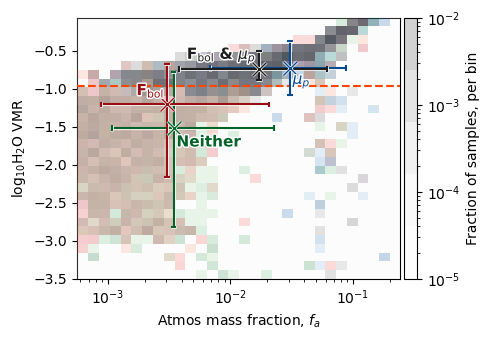

In [67]:
fig,ax = plt.subplots(1,1, figsize=(5,3.5))

xkey = "frac_atm"
ykey = "log_vmr_H2O" # μ_phot

nbins = 30
nlevs = 6
scat_val = 1.0
scat_al = 0.03
vmr_min = 10**(-3.5)
filter_sigma = 0.0
al_min = 0.05
al_max = 0.3

plot_types = ["hist2d"]#, "scatter", ]

cmap_dict = {
    "Fbol+MMW":  "Greys",
    "Fbol":      "Reds",
    "MMW":       "Blues",
    "Neither":   "Greens"
}

hist = {}
xmin, xmax = np.inf, -np.inf
ymin, ymax = np.inf, -np.inf
nsamps = 1
for k in cases.keys():

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    if xkey.startswith("log_vmr"):
        x = np.clip(x, np.log10(vmr_min), 0)
    if ykey.startswith("log_vmr"):
        y = np.clip(y, np.log10(vmr_min), 0)

    if varprops[xkey].log:
        x = np.log10(x)
    if varprops[ykey].log:
        y = np.log10(y)

    xmin = min(xmin, np.amin(x))
    xmax = max(xmax, np.amax(x))
    ymin = min(ymin, np.amin(y))
    ymax = max(ymax, np.amax(y))

    nsamps = max(nsamps, len(x))


for k in cases.keys():

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    if varprops[xkey].log:
        x = np.log10(x)
    if varprops[ykey].log:
        y = np.log10(y)

    counts, xbins, ybins = np.histogram2d(x,y, bins=nbins, range=[[xmin,xmax],[ymin,ymax]])


    if varprops[xkey].log:
        xbins = 10**xbins
    if varprops[ykey].log:
        ybins = 10**ybins

    hist[k] = (counts.T, xbins, ybins)


zorder = 20
for k in cases.keys():
    print(k)
    print("    "+cmap_dict[k])


    cmap_orig = deepcopy(plt.get_cmap(cmap_dict[k]))
    cmap = cmap_orig(np.arange(cmap_orig.N))
    cmap[:,-1] =  np.linspace(al_min, al_max, cmap_orig.N)
    cmap = mpl.colors.ListedColormap(cmap)
    cmap.set_under([0,0,0,0])

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale
    nsamps = len(x)
    print(f"    Nsamps: {nsamps}")

    counts = hist[k][0]
    counts /= nsamps

    counts = np.clip(counts, 1e-5, 1)
    min_counts = np.amin(counts)
    max_counts = np.amax(counts)
    print(f"    Counts: {min_counts:.1e} - {max_counts:.1e}")

    xbins = hist[k][1]
    ybins = hist[k][2]
    xbins_mid = (xbins[1:]+xbins[:-1])/2
    ybins_mid = (ybins[1:]+ybins[:-1])/2

    norm = mpl.colors.LogNorm(vmin=min_counts, vmax=max_counts)
    levels = 10**np.arange(np.log10(min_counts), np.log10(max_counts), (np.log10(max_counts)-np.log10(min_counts))/nlevs)
    # levels = nlevs

    # smooth data before plotting on contour
    if filter_sigma > 0:
        counts = sp.ndimage.gaussian_filter(counts, sigma=filter_sigma)

    for i,plot_type in enumerate(plot_types):

        if plot_type=="scatter":
            ax.scatter(x,y, color=cmap_orig(scat_val), alpha=scat_al, s=3, edgecolors='none',
                       rasterized=True, zorder=zorder+i)

        elif plot_type == "hist2d":
            ax.pcolormesh(xbins_mid, ybins_mid, counts,
                                cmap=cmap, norm=norm, rasterized=True, zorder=zorder+i
                                )

        elif plot_type == "contourf":
            ax.contourf(xbins_mid, ybins_mid, counts, levels=levels,
                                cmap=cmap, norm=norm, zorder=zorder+i
                                )

        elif plot_type == "contour":
            ax.contour(xbins_mid, ybins_mid, counts, levels=levels, linewidths=0.7,
                                cmap=cmap, norm=norm, zorder=zorder+i
                                )

        else:
            raise ValueError("Invalid plot type:", plot_type)

    _pe_text = [mpl.patheffects.Stroke(linewidth=2, foreground='w'), mpl.patheffects.Normal()]


    lbl = f"{k}"
    col = cmap(0.9)
    x0 = np.median(x)
    y0 = np.median(y)
    xerr = [[x0-np.percentile(x, 16)], [np.percentile(x, 84)-x0]]
    yerr = [[y0-np.percentile(y, 16)], [np.percentile(y, 84)-y0]]
    print(f"    {xkey:16s}: {x0:g} ({xerr[0][0]:g} , {xerr[1][0]:g})")
    print(f"    {ykey:16s}: {y0:g} ({yerr[0][0]:g} , {yerr[1][0]:g})")
    ax.errorbar([x0], [y0], xerr=xerr, yerr=yerr,
                color=col, alpha=1, path_effects=_pe_text, capsize=2, capthick=1.5, elinewidth=1.5,
                marker='x', markersize=10, label=lbl,zorder=50)

    if "Fbol" in lbl:
        offset = (-2,10)
        ha = 'right'
    else:
        offset = (2,-10)
        ha = 'left'
    lbl = lbl.replace("Fbol",r"F$_{\text{bol}}$")
    lbl = lbl.replace("MMW",r"$\mu_p$")
    lbl = lbl.replace("+"," & ")
    ax.annotate(lbl, (x0, y0), offset, color=col, weight='bold', ha=ha, va='center', alpha=1,
                textcoords='offset points',zorder=52, fontsize=11, path_effects=_pe_text)


if plot_type != ["scatter"]:
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, label="Fraction of samples, per bin", boundaries=levels)
    cbar.ax.set_yscale("log")
    # cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.0f'))

ax.axhline(y=np.log10(0.11), ls='--', color=truth_color, zorder=zorder+20)

ax.set_ylabel(varprops[ykey].label)
ax.set_xlabel(varprops[xkey].label)
if varprops[xkey].log:
    ax.set_xscale("log")
if varprops[ykey].log:
    ax.set_yscale("log")

ax.set_xlim(np.amin(xbins), np.amax(xbins))
ax.set_ylim(np.amin(ybins), np.amax(ybins))

# ax.legend(ncols=2)
# ax.set_title(planet.replace("_"," "))
fig.tight_layout()

fig.savefig(os.path.join(outdir,"ia_Fbol.pdf"),  dpi=DPI, bbox_inches="tight")
plt.show()